In [144]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns

gender_path = Path('2014-2023_Index_World_economic_forum.xlsx')
gender_data = pd.read_excel(gender_path)
gender_data.head(3)

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Iceland,0.8594,0.881,0.874,0.878,0.858,NaN,0.877,0.892,0.908,0.912
1,Norway,0.8374,0.850,0.842,0.830,0.835,NaN,0.842,0.849,0.845,0.879
2,Sweden,0.8165,0.823,0.815,0.816,0.822,NaN,0.820,0.823,0.822,0.815


In [145]:
northern_country = ['Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 'Lithuania', 'Norway', 'Sweden', 'United Kingdom']
southern_country = ['Albania', 'Bosnia', 'croatia', 'Cyprus', 'Greece', 'Italy', 'Malta', 'Montenegro', 'Portugal', 'Serbia', 'Slovenia', 'Spain', 'North Macedonia']
western_country = ['Austria', 'Belgium', 'France', 'Germany', 'Luxembourg', 'Netherlands', 'Switzerland']
eastern_country = ['Czech Republic', 'Slovakia', 'Ukrain', 'Poland', 'Hungary', 'Moldova','Bosnia and Herzegovina', 'Bulgaria', 'Romania']

In [146]:
year_cols = [c for c in gender_data.columns if c != 'Country']
gender_data[year_cols] = gender_data[year_cols].astype(float)
gender_data[2019] = (gender_data[2018] + gender_data[2020]) / 2

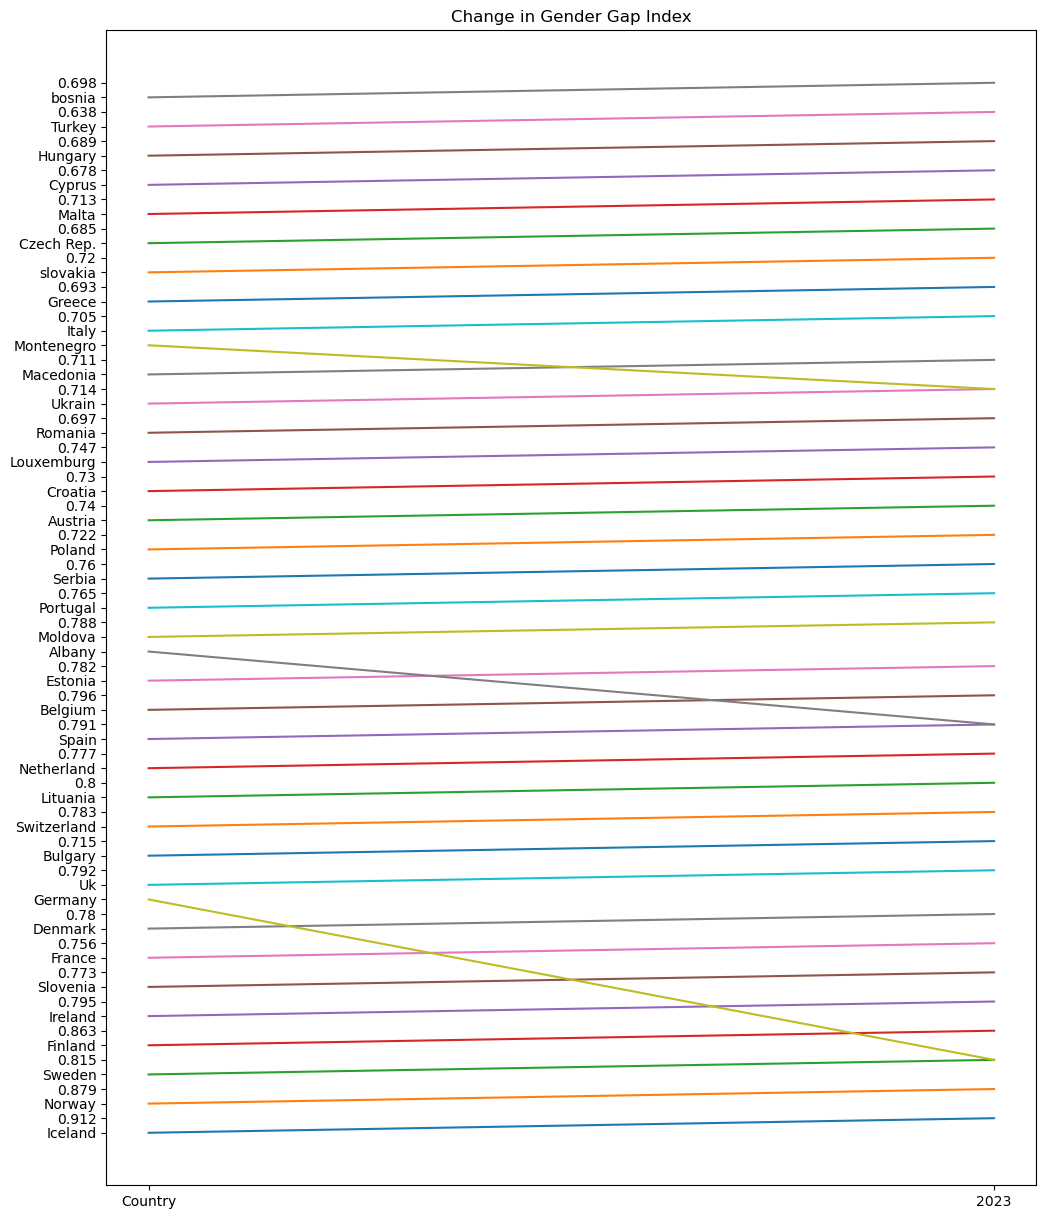

In [147]:
start = gender_data.columns[0]
end = gender_data.columns[-1]

plt.figure(figsize=(12,15))

for country in gender_data.index:
    plt.plot([0,1], [gender_data.loc[country, start], gender_data.loc[country, end]])

plt.xticks([0,1], [start, end])
plt.title("Change in Gender Gap Index")
plt.show()

In [148]:
#remove index column on x axis and transpose the data frame to have years as columns and countries as rows
gender_data = gender_data.set_index('Country').T
gender_data.head(3)

Country,Iceland,Norway,Sweden,Finland,Ireland,Slovenia,France,Denmark,Germany,Uk,...,Montenegro,Italy,Greece,slovakia,Czech Rep.,Malta,Cyprus,Hungary,Turkey,bosnia
2014,0.8594,0.8374,0.8165,0.8453,0.785,0.7443,0.7588,0.8025,0.778,0.7383,...,0.6934,0.6973,0.6784,0.6806,0.6737,0.6707,0.6741,0.6759,0.6183,NaN
2015,0.8810,0.8500,0.8230,0.8500,0.807,0.7840,0.7610,0.7670,0.779,0.7580,...,0.6890,0.7260,0.6850,0.6750,0.6870,0.6680,0.6710,0.6720,0.6240,NaN
2016,0.8740,0.8420,0.8150,0.8450,0.797,0.7860,0.7550,0.7540,0.766,0.7520,...,0.6810,0.7190,0.6800,0.6790,0.6900,0.6640,0.6840,0.6690,0.6230,0.685


In [149]:
# Add a column with the European average for each year
gender_data['European Average'] = gender_data.mean(axis=1)
gender_data.head(3)

Country,Iceland,Norway,Sweden,Finland,Ireland,Slovenia,France,Denmark,Germany,Uk,...,Italy,Greece,slovakia,Czech Rep.,Malta,Cyprus,Hungary,Turkey,bosnia,European Average
2014,0.8594,0.8374,0.8165,0.8453,0.785,0.7443,0.7588,0.8025,0.778,0.7383,...,0.6973,0.6784,0.6806,0.6737,0.6707,0.6741,0.6759,0.6183,NaN,0.732089
2015,0.8810,0.8500,0.8230,0.8500,0.807,0.7840,0.7610,0.7670,0.779,0.7580,...,0.7260,0.6850,0.6750,0.6870,0.6680,0.6710,0.6720,0.6240,NaN,0.738054
2016,0.8740,0.8420,0.8150,0.8450,0.797,0.7860,0.7550,0.7540,0.766,0.7520,...,0.7190,0.6800,0.6790,0.6900,0.6640,0.6840,0.6690,0.6230,0.685,0.733079


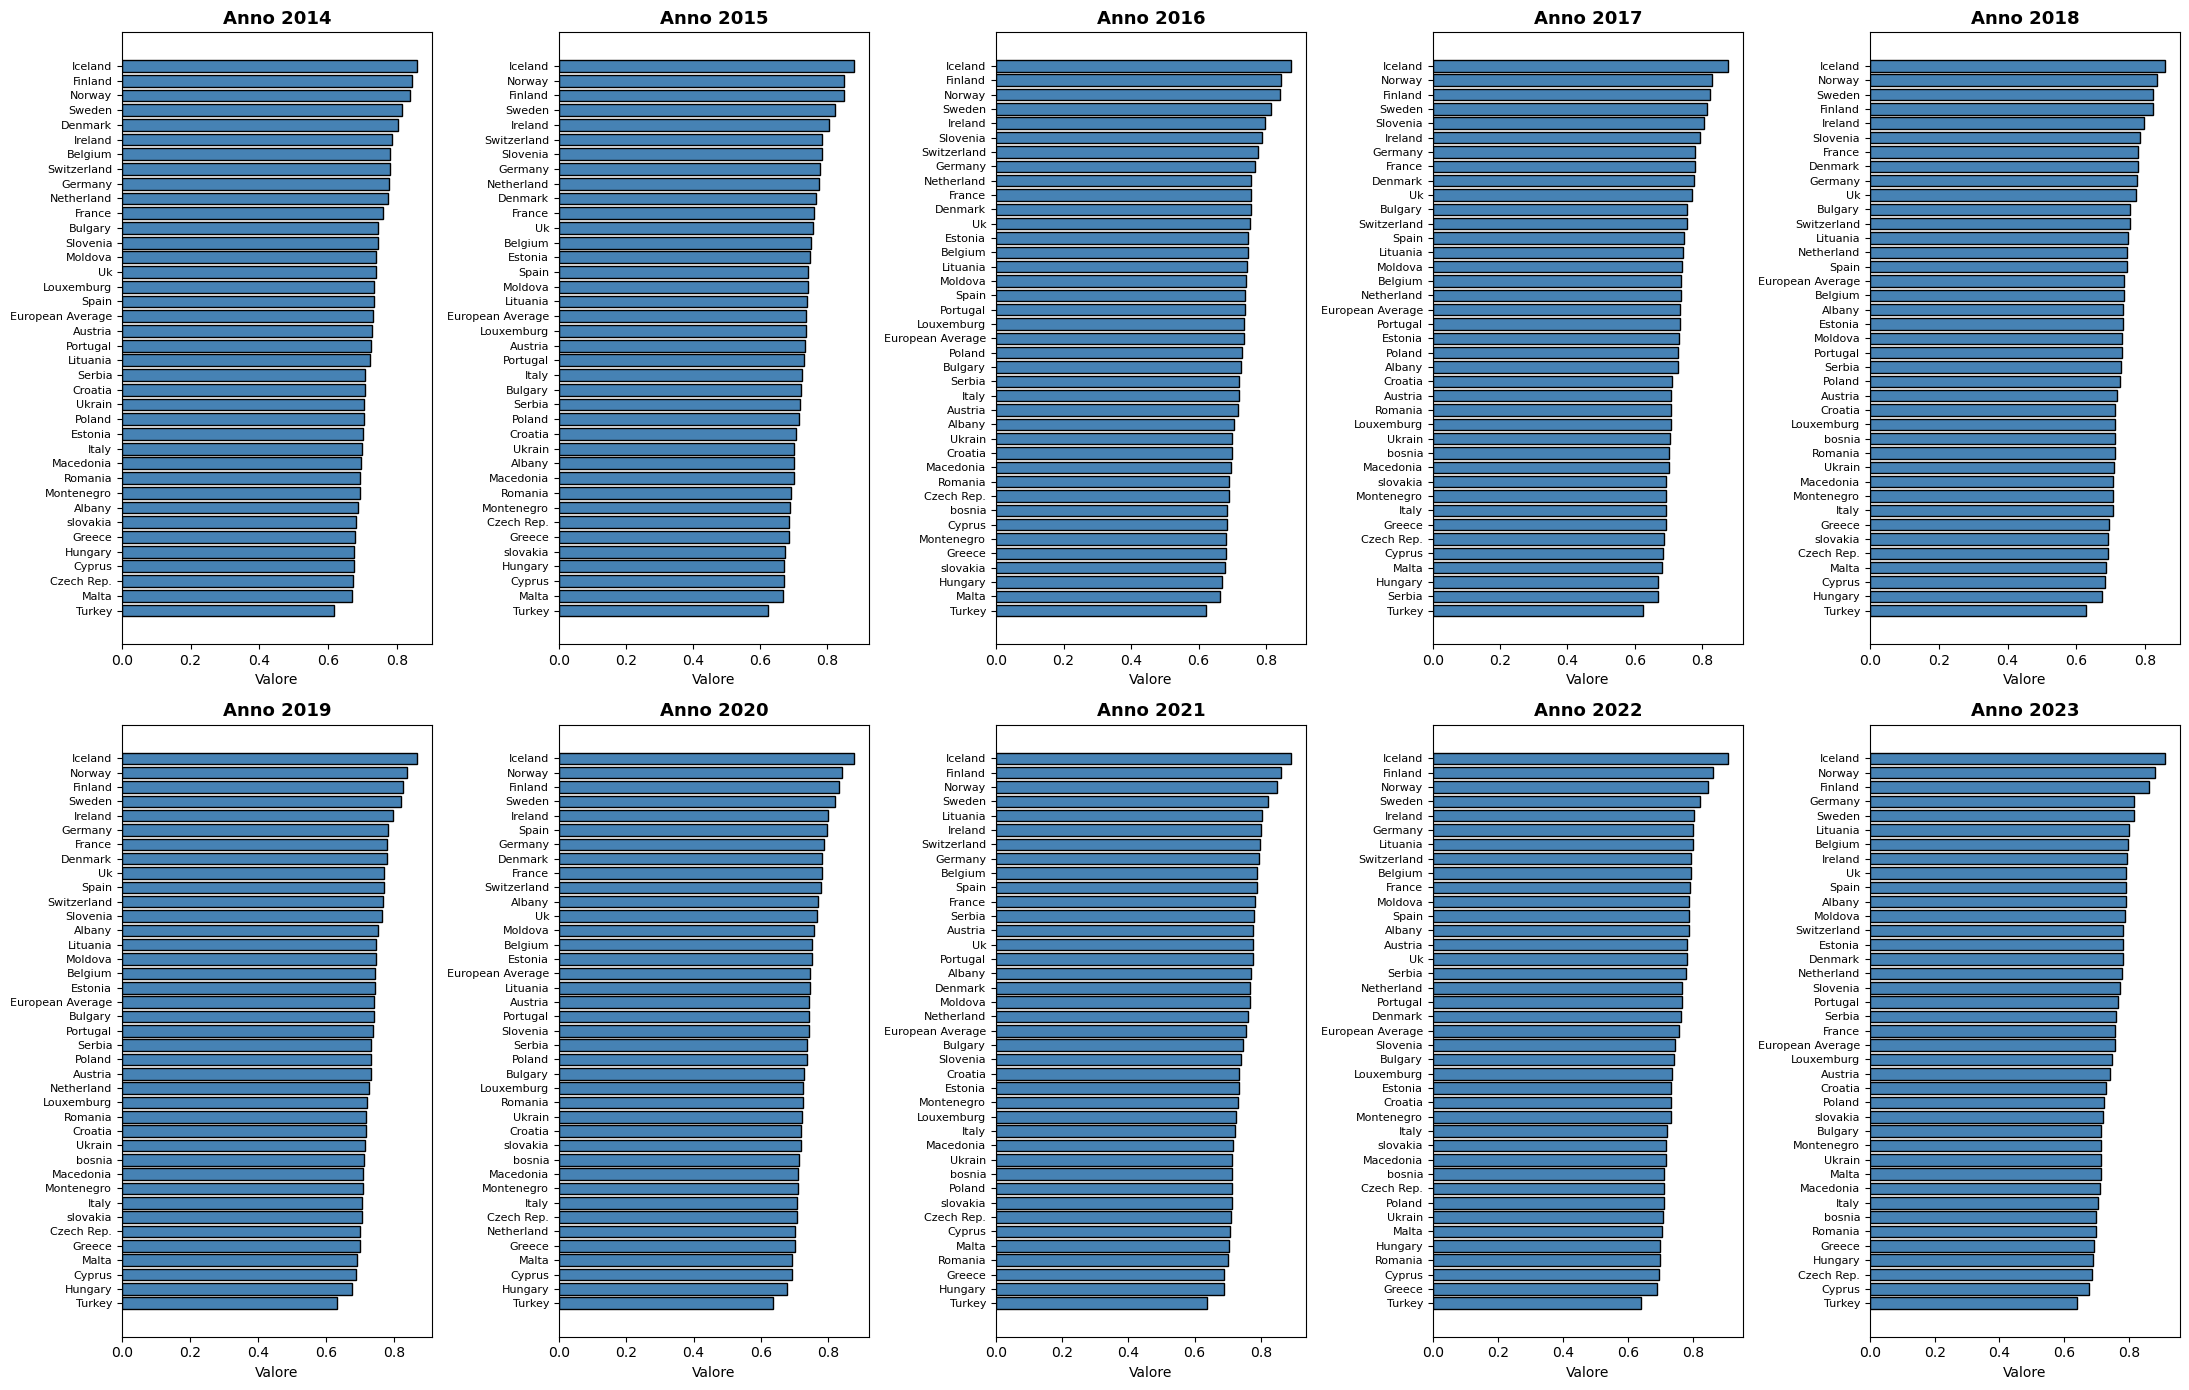

In [150]:
fig, axes = plt.subplots(2, 5, figsize=(22, 14))
axes = axes.flatten()

for i, year in enumerate(year_cols):
    ax = axes[i]
    # Ordina dal maggiore al minore ed elimina eventuali NaN
    serie = gender_data.loc[year].dropna().sort_values(ascending=True)

    ax.barh(serie.index, serie.values, color="steelblue", edgecolor="black")
    ax.set_title(f"Anno {year}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Valore")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()